In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [5]:
# Load data
RT_detailed = pd.read_parquet(Path("../data/processed/rt_detailed.parquet"))

# Rename Travel_Distance column to Distance for df RT_detailed
RT_detailed = RT_detailed.rename(columns={'Travel_Distance': 'Distance'})

In [6]:
display(RT_detailed.head(3))

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Prev_Bay,Prev_Level,Prev_Slot,Aisle2,Bay2,Prev_Aisle2,Prev_Bay2,LocKey,PrevLocKey,Distance
0,PickPut,102,5.0,4477558,14469,6,2024-05-28 07:54:14.920,104027,2024-05-28 07:49:21.627,112687,...,142,10,<NA>,231,146,222,142,231:146,222:142,1208.0
1,PickPut,102,5.0,4477558,11772,6,2024-05-28 07:55:19.720,96167,2024-05-28 07:54:14.920,104027,...,146,10,<NA>,231,114,231,146,231:114,231:146,192.0
2,PickPut,102,5.0,4477558,11532,11,2024-05-28 07:59:02.700,115278,2024-05-28 07:55:19.720,96167,...,114,20,<NA>,232,110,231,114,232:110,231:114,340.0


In [7]:
# distinct numer of days in RT_detailed
RT_detailed["Date"] = RT_detailed["Timestamp"].dt.date
distinct_days = RT_detailed["Date"].nunique()
print(f"Number of distinct days in RT_detailed: {distinct_days}")

Number of distinct days in RT_detailed: 13


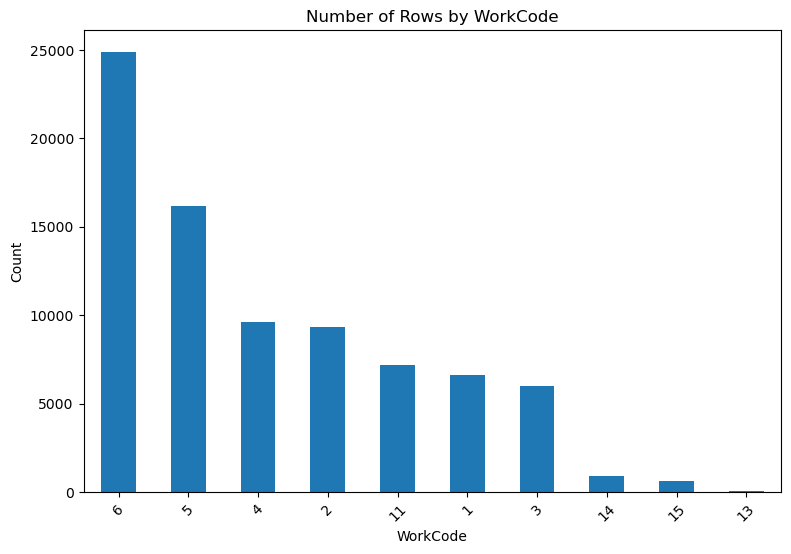

In [8]:
# bar plot of number of rows by WorkCode
# remove those values = 'nan' and remove all .0 from the WorkCode column
RT_detailed = RT_detailed[RT_detailed["WorkCode"] != "nan"]
RT_detailed["WorkCode"] = RT_detailed["WorkCode"].str.replace(".0", "", regex=False)

plt.figure(figsize=(9, 6))
RT_detailed["WorkCode"].value_counts().plot(kind="bar")
plt.title("Number of Rows by WorkCode")
plt.xlabel("WorkCode")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [9]:
# load rt_detailed2.parquet
RT_detailed2 = pd.read_parquet(Path("../data/processed/rt_detailed2.parquet"))
display(RT_detailed2.head(3))

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Prev_Bay,Prev_Level,Prev_Slot,Aisle2,Bay2,Prev_Aisle2,Prev_Bay2,LocKey,PrevLocKey,Travel_Distance
0,PickPut,102,5,4181343,13648,9,2023-10-05 11:59:33,100298,NaT,<NA>,...,<NA>,<NA>,<NA>,233,233,<NA>,<NA>,233:233,<NA>:<NA>,NaN
1,PickPut,102,5,4181343,13648,9,2023-10-05 11:59:33,100298,2023-10-05 11:59:33,100298,...,233,10,<NA>,233,233,233,233,233:233,233:233,0.0
2,PickPut,102,5,4181343,13648,9,2023-10-05 11:59:33,100298,2023-10-05 11:59:33,100298,...,233,10,<NA>,233,233,233,233,233:233,233:233,0.0


In [10]:
# dimension of RT_detailed2
print(f"RT_detailed2 shape: {RT_detailed2.shape}")

RT_detailed2 shape: (13774106, 30)


In [11]:
# Print distinct number of days and date range
print(f"Number of distinct days: {RT_detailed2['Timestamp'].dt.date.nunique()}")
print(f"Date range: {RT_detailed2['Timestamp'].min()} to {RT_detailed2['Timestamp'].max()}")

Number of distinct days: 621
Date range: 2023-10-03 13:31:45 to 2026-01-05 21:49:56


In [12]:
# first 100 values of Time_Delta_sec
display(RT_detailed2["Time_Delta_sec"].head(100))

0      NaN
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
95     0.0
96     0.0
97    97.0
98     0.0
99     0.0
Name: Time_Delta_sec, Length: 100, dtype: float64

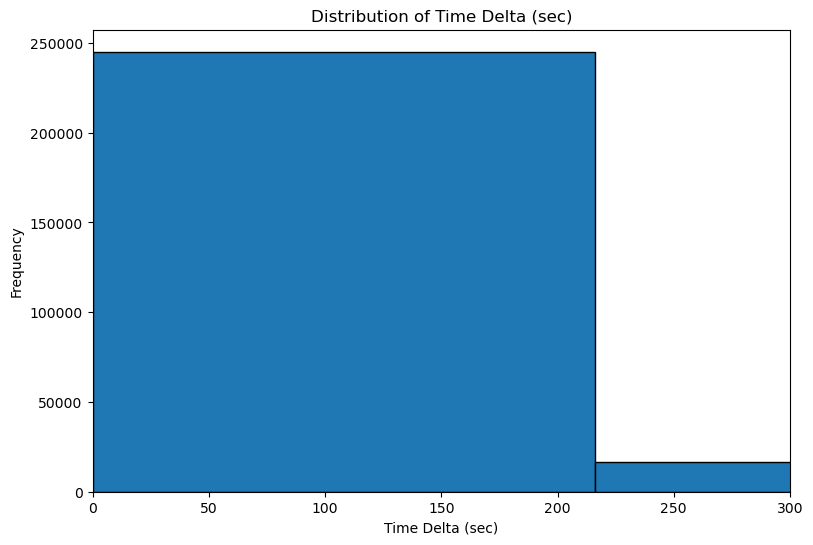

In [13]:
# distribution of time_delta_sec
# remove 0 and negative values
RT_detailed2_gt0 = RT_detailed2[RT_detailed2["Time_Delta_sec"] > 0]
# filter the days in 2025
RT_detailed2_gt0_2025 = RT_detailed2_gt0[RT_detailed2_gt0["Timestamp"].dt.year == 2025]
plt.figure(figsize=(9, 6))
plt.hist(RT_detailed2_gt0_2025["Time_Delta_sec"], bins=50, edgecolor="k")
plt.title("Distribution of Time Delta (sec)")
plt.xlabel("Time Delta (sec)")
plt.ylabel("Frequency")
plt.xlim(0, 300)  # limit x-axis to 300 seconds
plt.show()

In [14]:
# load RT_Activity2.csv from ../data/database_backups_csv/RT/
RT_Activity2 = pd.read_csv(Path("../data/database_backups_csv/RT/RT_Activity2.csv"))

In [15]:
# display first 20 rows for User 102 on 2026-01-05
user_102_1005 = RT_Activity2[(RT_Activity2["UserID"] == 102) & (RT_Activity2["Timestamp"].str.startswith("2025-10-06"))].copy()
# sort by timestamp
user_102_1005["Timestamp"] = pd.to_datetime(user_102_1005["Timestamp"])
user_102_1005 = user_102_1005.sort_values("Timestamp")
display(user_102_1005.head(20))

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID
12795492,PickPut,102,5,5329859,11927,12,2025-10-06 13:31:06,100298
12805451,PickPut,102,5,5329859,11927,12,2025-10-06 13:31:06,100298
12853352,PickPut,102,5,5329859,11927,12,2025-10-06 13:31:06,100298
12795493,PickPut,102,5,5329859,13761,12,2025-10-06 13:32:17,100298
12805452,PickPut,102,5,5329859,13761,12,2025-10-06 13:32:17,100298
12853353,PickPut,102,5,5329859,13761,12,2025-10-06 13:32:17,100298


In [16]:
# for RT_Activity2, count user average number of rows per day, compared to user average number of distinct timestamps per day
user_daily_counts = RT_Activity2.groupby(["UserID", RT_Activity2["Timestamp"].str[:10]]).size().reset_index(name="RowCount")
user_daily_distinct_timestamps = RT_Activity2.groupby(["UserID", RT_Activity2["Timestamp"].str[:10]])["Timestamp"].nunique().reset_index(name="DistinctTimestamps")
user_daily_summary = pd.merge(user_daily_counts, user_daily_distinct_timestamps, on=["UserID", "Timestamp"])

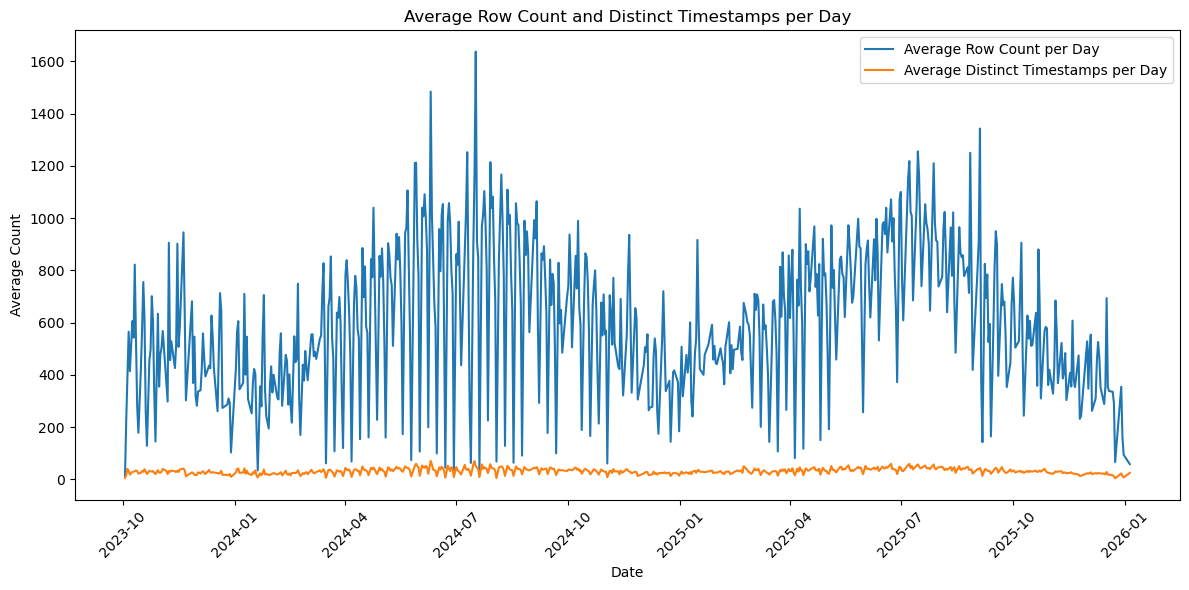

In [17]:
# plot in the same lines plot, average RowCount and average DistinctTimestamps per day across all users
daily_summary = user_daily_summary.groupby("Timestamp").agg({"RowCount": "mean", "DistinctTimestamps": "mean"}).reset_index()
daily_summary["Timestamp"] = pd.to_datetime(daily_summary["Timestamp"])
plt.figure(figsize=(12, 6))
plt.plot(daily_summary["Timestamp"], daily_summary["RowCount"], label="Average Row Count per Day")
plt.plot(daily_summary["Timestamp"], daily_summary["DistinctTimestamps"], label="Average Distinct Timestamps per Day")
plt.title("Average Row Count and Distinct Timestamps per Day")
plt.xlabel("Date")
plt.ylabel("Average Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# display users 77, 102, 501, before 2023-10-10, sorted by UserID and Timestamp
user_daily_summary_filtered = user_daily_summary[user_daily_summary["UserID"].isin([77, 102, 501])]
user_daily_summary_filtered["Timestamp"] = pd.to_datetime(user_daily_summary_filtered["Timestamp"])
user_daily_summary_filtered = user_daily_summary_filtered[user_daily_summary_filtered["Timestamp"] < pd.to_datetime("2023-10-10")]
user_daily_summary_filtered = user_daily_summary_filtered.sort_values(["UserID", "Timestamp"])
display(user_daily_summary_filtered.head(15))

/var/folders/hs/r4ck14j54v17d80mrc1wt5kw0000gn/T/ipykernel_38319/3305177275.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_daily_summary_filtered["Timestamp"] = pd.to_datetime(user_daily_summary_filtered["Timestamp"])


,UserID,Timestamp,RowCount,DistinctTimestamps
0,77,2023-10-04,105,4
1,77,2023-10-05,24,1
2,77,2023-10-09,25,3
871,102,2023-10-05,10,2
872,102,2023-10-06,22,4
873,102,2023-10-07,42,3
6502,501,2023-10-04,175,27
6503,501,2023-10-05,289,38
6504,501,2023-10-06,35,7
6505,501,2023-10-09,497,44


In [19]:
# display first 20 rows for User 102 on 2023/10/05 in RT_detailed2
user_102_1005_detailed2 = RT_detailed2[(RT_detailed2["UserID"] == '102') & (RT_detailed2["Timestamp"].dt.date == pd.to_datetime("2023-10-05").date())].copy()
# display first 10 columns only
user_102_1005_detailed2 = user_102_1005_detailed2.iloc[:, :15]
display(user_102_1005_detailed2.head(20))

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,Time_Delta_sec,ProductCode,UnitOfMeasure,Weight,Cube
0,PickPut,102,5,4181343,13648,9,2023-10-05 11:59:33,100298,NaT,<NA>,NaN,12124,NaN,3600.0,NaN
1,PickPut,102,5,4181343,13648,9,2023-10-05 11:59:33,100298,2023-10-05 11:59:33,100298,0.0,12124,NaN,3600.0,NaN
2,PickPut,102,5,4181343,13648,9,2023-10-05 11:59:33,100298,2023-10-05 11:59:33,100298,0.0,12124,NaN,3600.0,NaN
3,PickPut,102,5,4181343,13648,9,2023-10-05 11:59:33,100298,2023-10-05 11:59:33,100298,0.0,12124,NaN,3600.0,NaN
4,PickPut,102,5,4181343,13648,9,2023-10-05 11:59:33,100298,2023-10-05 11:59:33,100298,0.0,12124,NaN,3600.0,NaN
5,PickPut,102,5,4181343,13577,6,2023-10-05 12:00:26,100298,2023-10-05 11:59:33,100298,53.0,10361,NaN,3604.0,NaN
6,PickPut,102,5,4181343,13577,6,2023-10-05 12:00:26,100298,2023-10-05 12:00:26,100298,0.0,10361,NaN,3604.0,NaN
7,PickPut,102,5,4181343,13577,6,2023-10-05 12:00:26,100298,2023-10-05 12:00:26,100298,0.0,10361,NaN,3604.0,NaN
8,PickPut,102,5,4181343,13577,6,2023-10-05 12:00:26,100298,2023-10-05 12:00:26,100298,0.0,10361,NaN,3604.0,NaN
9,PickPut,102,5,4181343,13577,6,2023-10-05 12:00:26,100298,2023-10-05 12:00:26,100298,0.0,10361,NaN,3604.0,NaN


In [20]:
# load OE data
OE_detailed = pd.read_parquet(Path("../data/processed/oe_detailed.parquet"))
display(OE_detailed.head(3))

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Prev_Bay,Prev_Level,Prev_Slot,Aisle2,Bay2,Prev_Aisle2,Prev_Bay2,LocKey,PrevLocKey,Travel_Distance
0,PickPut,143,30,7717848,49658,160,2025-09-08 12:11:50.830,35192,NaT,<NA>,...,<NA>,<NA>,<NA>,40,19,<NA>,<NA>,40|19|||,<NA>|<NA>|||,NaN
1,PickPut,143,30,7717860,460,50,2025-09-08 12:12:18.127,422,2025-09-08 12:11:50.830,35192,...,19,2,2,40,18,40,19,40|18|||,40|19|||,21.0
2,PickPut,143,30,7717908,460,100,2025-09-08 12:15:46.650,422,2025-09-08 12:12:18.127,422,...,18,2,1,40,18,40,18,40|18|||,40|18|||,0.0


In [21]:
# EDA on product occurrance frequency
product_counts = OE_detailed["ProductID"].value_counts()

In [22]:
# what top percentage of top products account for 25, 50, 75, 90, 95% of total occurrences
total_occurrences = product_counts.sum()
cumulative_occurrences = product_counts.cumsum()
percentages = cumulative_occurrences / total_occurrences * 100
thresholds = [25, 50, 75, 90, 95]
# Show count and percentage of products that account for each threshold
for threshold in thresholds:
    top_products = percentages[percentages <= threshold]
    print(f"Top {len(top_products)} products account for {threshold}% of total occurrences")

Top 83 products account for 25% of total occurrences
Top 343 products account for 50% of total occurrences
Top 1100 products account for 75% of total occurrences
Top 2625 products account for 90% of total occurrences
Top 3948 products account for 95% of total occurrences


In [27]:
# for all warehouse(OE/OF/RT) and workcode combiniations, compute their mean and median time delta, for all those less than 300 seconds, and display in a table
for warehouse in ["OE", "OF", "RT"]:
    for workcode in ["10", "20", "30", "1", "2", "3", "4", "5", "6"]:
        if warehouse == "OE":
            df = OE_detailed
        elif warehouse == "OF":
            df = pd.read_parquet(Path("../data/processed/of_detailed.parquet"))
        else:
            df = RT_detailed2
        
        df_filtered = df[(df["WorkCode"] == workcode) & (df["Time_Delta_sec"] < 300)]
        mean_time_delta = df_filtered["Time_Delta_sec"].mean()
        median_time_delta = df_filtered["Time_Delta_sec"].median()
        print(f"Warehouse: {warehouse}, WorkCode: {workcode}, Mean Time Delta: {mean_time_delta:.2f} sec, Median Time Delta: {median_time_delta:.2f} sec")

Warehouse: OE, WorkCode: 10, Mean Time Delta: 84.99 sec, Median Time Delta: 68.49 sec
Warehouse: OE, WorkCode: 20, Mean Time Delta: 36.43 sec, Median Time Delta: 0.47 sec
Warehouse: OE, WorkCode: 30, Mean Time Delta: 45.89 sec, Median Time Delta: 33.02 sec
Warehouse: OE, WorkCode: 1, Mean Time Delta: nan sec, Median Time Delta: nan sec
Warehouse: OE, WorkCode: 2, Mean Time Delta: nan sec, Median Time Delta: nan sec
Warehouse: OE, WorkCode: 3, Mean Time Delta: nan sec, Median Time Delta: nan sec
Warehouse: OE, WorkCode: 4, Mean Time Delta: nan sec, Median Time Delta: nan sec
Warehouse: OE, WorkCode: 5, Mean Time Delta: nan sec, Median Time Delta: nan sec
Warehouse: OE, WorkCode: 6, Mean Time Delta: nan sec, Median Time Delta: nan sec
Warehouse: OF, WorkCode: 10, Mean Time Delta: 66.07 sec, Median Time Delta: 52.30 sec
Warehouse: OF, WorkCode: 20, Mean Time Delta: 33.46 sec, Median Time Delta: 0.50 sec
Warehouse: OF, WorkCode: 30, Mean Time Delta: 60.23 sec, Median Time Delta: 45.74 sec
